# Zpracování sekvenčních dat

**Aplikace**

*   Predikce hodnot časových řad
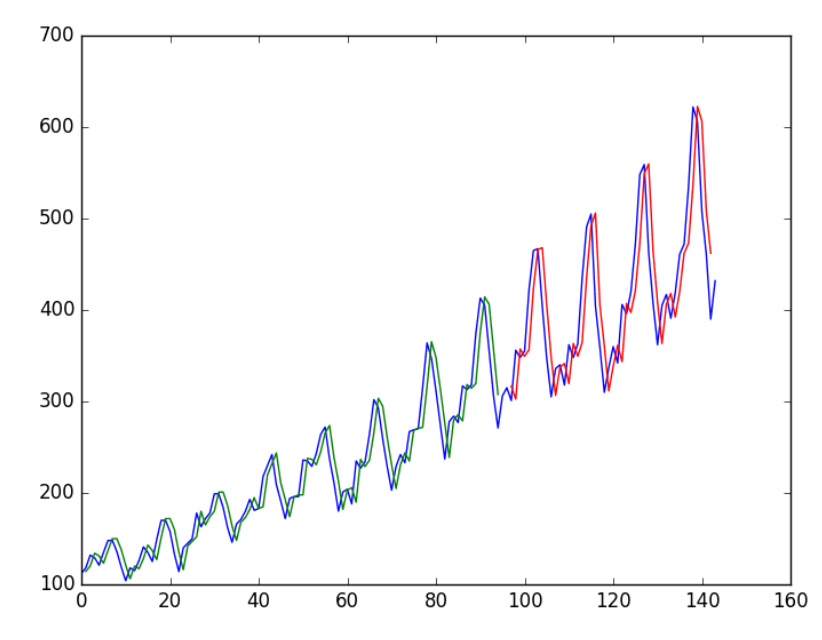

*   Klasifikace časových řad

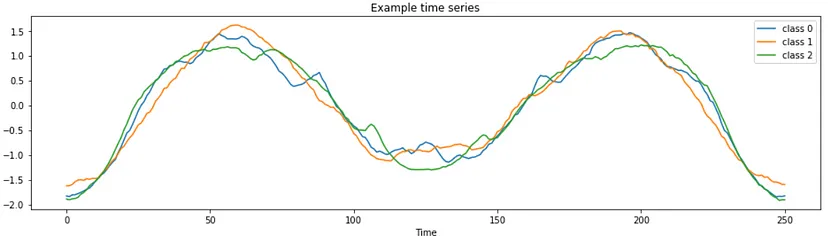

* Generování textu

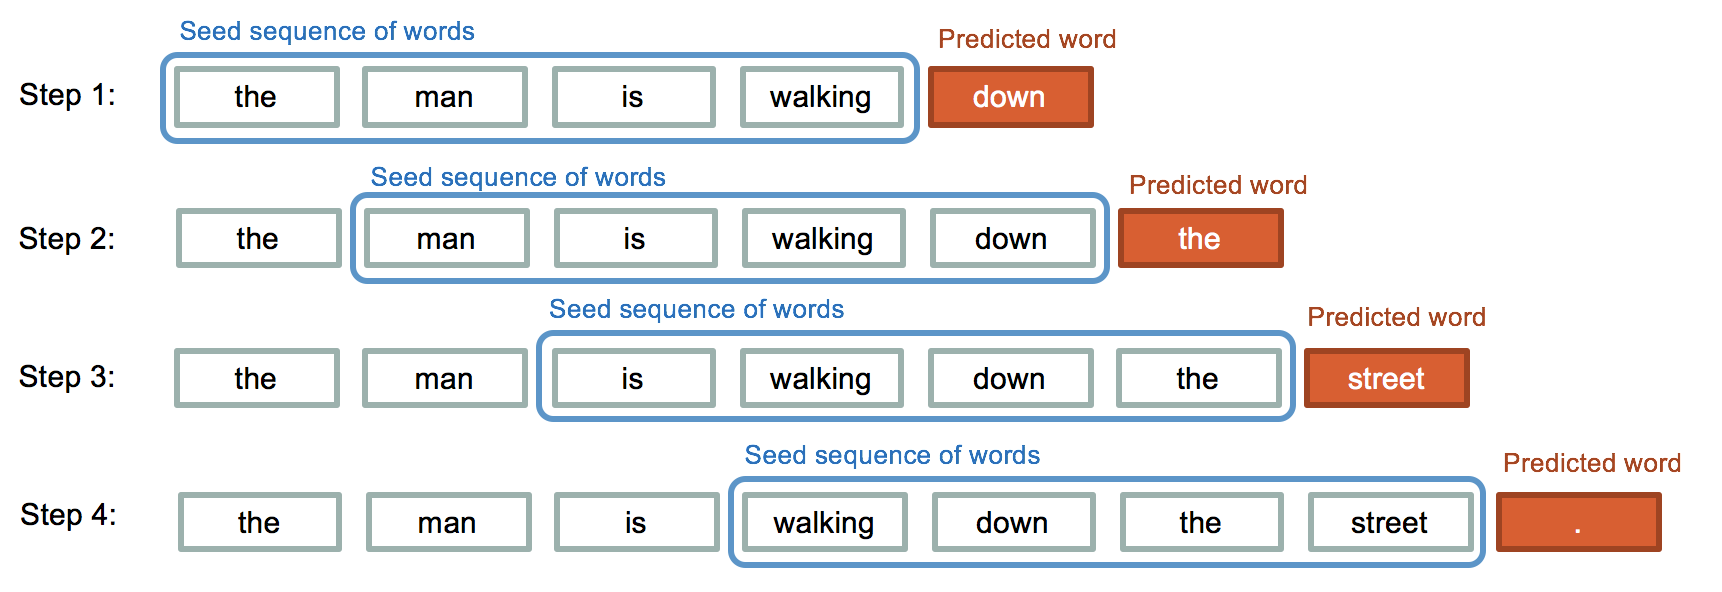


# Reprezentace sekvenčních dat

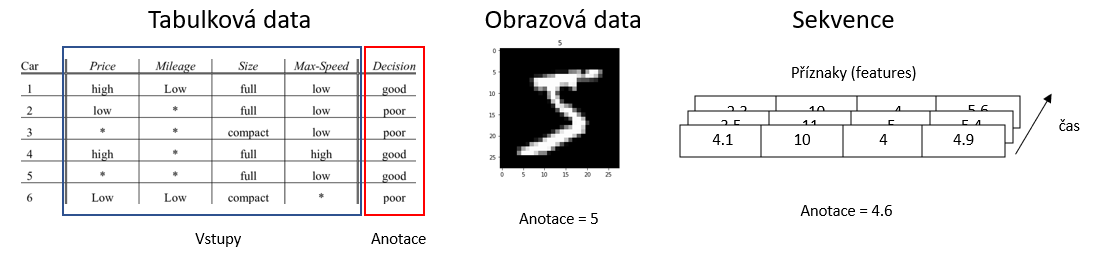

# Příklad 1

Predikce ranní teploty (v 8:00) pro následující den

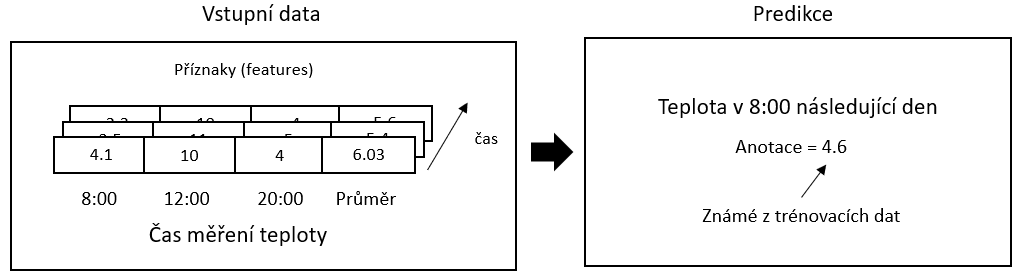

# Příklad 2

Predikce teploty za 24 hod. na základě meteorologických měření tlaku, teploty, vlhkosti, atd. v předchozích 5 dnech

In [ ]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

In [ ]:
import os
fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print("Měřené parametry:")
print(header)

print("\nVzorek č. 1:")
print(lines[0])

print("\nPočet vzorků v datasetu:")
print(len(lines))

**Příprava a analýza dat**



In [3]:
import numpy as np
temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))
for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]

In [ ]:
from matplotlib import pyplot as plt
plt.plot(range(len(temperature)), temperature)

In [ ]:
print("Naměřená data za prvních 10 dní:")
plt.plot(range(1440), temperature[:1440])

**Reprezentace dat v programu**

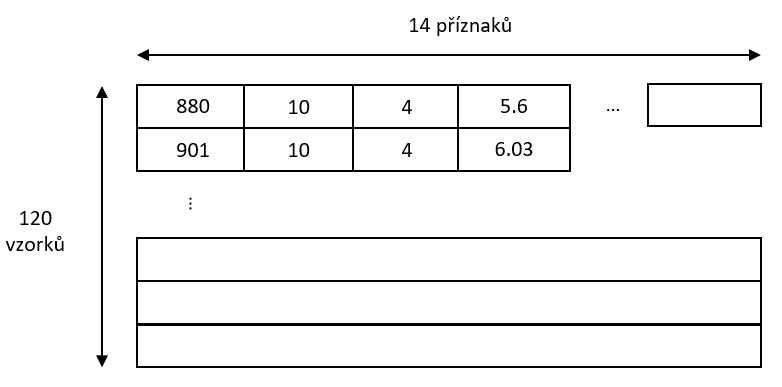

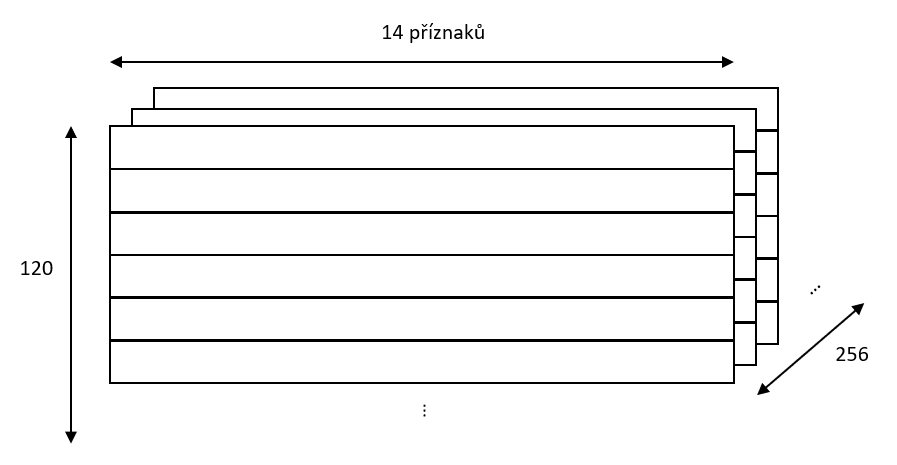

**Nastavení velikosti trénovacích/validačních/testovacích podmnožin**

In [4]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples

**Preprocessing dat**

Před vstupem do neuronové sítě vhodné data normalizovat (odečtení střední hodnoty a dělení směrodatnou odchylkou)

In [5]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

**Datasety**

Dataset je ze surových CSV dat vytvořen pomocí Keras funkce
```
timeseries_dataset_from_array
```

In [6]:
from tensorflow import keras

sampling_rate = 6 # V datasetu využijeme měření 1x za hodinu
sequence_length = 120 # Délka trénovací sekvence = 5 dní
delay = sampling_rate * (sequence_length + 24 - 1) # Delay 5 + 1 dní
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples)

Ukázka rozměrů jedné trénovací dávky (tzv. batch)

In [ ]:
train_sequence_batch, targets = next(iter(train_dataset))
print(train_sequence_batch.shape)
print(targets.shape)

# Predikce - metoda 1

Základní deterministický přístup - teplota za 24 hodin bude stejná jako aktuální teplota


In [8]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


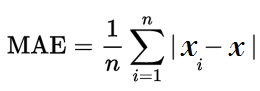

# Predikce - metoda 2 - plně propojená neuronová síť

In [9]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="jena_dense.krs",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

model = keras.models.load_model("jena_dense.krs")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 [==============================] - 55s 61ms/step - loss: 12.9043 - mae: 2.7832 - val_loss: 10.8083 - val_mae: 2.5874
Epoch 2/10
819/819 [==============================] - 38s 46ms/step - loss: 9.2267 - mae: 2.3898 - val_loss: 10.8130 - val_mae: 2.5946
Epoch 3/10
819/819 [==============================] - 47s 57ms/step - loss: 8.4123 - mae: 2.2816 - val_loss: 13.6402 - val_mae: 2.9113
Epoch 4/10
819/819 [==============================] - 47s 57ms/step - loss: 7.9375 - mae: 2.2141 - val_loss: 11.7599 - val_mae: 2.7040
Epoch 5/10
819/819 [==============================] - 37s 45ms/step - loss: 7.6150 - mae: 2.1705 - val_loss: 11.0542 - val_mae: 2.6140
Epoch 6/10
819/819 [==============================] - 38s 46ms/step - loss: 7.3459 - mae: 2.1313 - val_loss: 10.9700 - val_mae: 2.6034
Epoch 7/10
819/819 [==============================] - 47s 57ms/step - loss: 7.1365 - mae: 2.1037 - val_loss: 12.8053 - val_mae: 2.8320
Epoch 8/10
819/819 [==============================] - 

# Predikce - metoda 3 - rekurentní neuronová síť

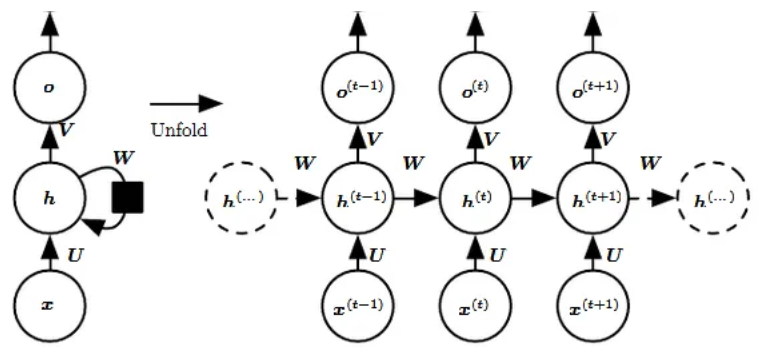

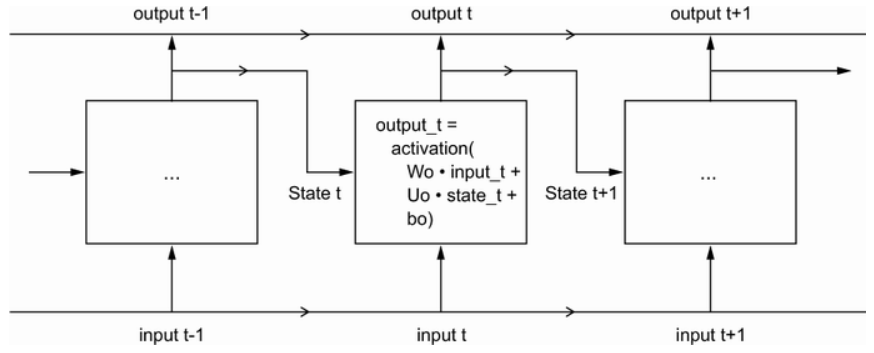

In [11]:
from tensorflow import keras
from tensorflow.keras import layers

num_features = 14
steps = 120

inputs = keras.Input(shape=(steps, num_features))
x = layers.SimpleRNN(16, return_sequences=True)(inputs)
x = layers.SimpleRNN(16, return_sequences=True)(x)
outputs = layers.SimpleRNN(16)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="jena_rnn.krs",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

model = keras.models.load_model("jena_rnn.krs")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 [==============================] - 304s 368ms/step - loss: 136.6349 - mae: 9.5639 - val_loss: 143.5105 - val_mae: 9.8498
Epoch 2/10
819/819 [==============================] - 296s 362ms/step - loss: 135.9916 - mae: 9.5201 - val_loss: 143.4974 - val_mae: 9.8511
Epoch 3/10
819/819 [==============================] - 298s 364ms/step - loss: 135.9264 - mae: 9.5095 - val_loss: 143.4428 - val_mae: 9.8394
Epoch 4/10
819/819 [==============================] - 294s 359ms/step - loss: 135.8920 - mae: 9.5051 - val_loss: 143.4512 - val_mae: 9.8422
Epoch 5/10
819/819 [==============================] - 294s 359ms/step - loss: 135.8630 - mae: 9.5009 - val_loss: 143.4511 - val_mae: 9.8385
Epoch 6/10
819/819 [==============================] - 294s 359ms/step - loss: 135.8353 - mae: 9.4962 - val_loss: 143.4825 - val_mae: 9.8464
Epoch 7/10
819/819 [==============================] - 296s 361ms/step - loss: 135.8235 - mae: 9.4947 - val_loss: 143.4544 - val_mae: 9.8395
Epoch 8/10
819/819 [

# Predikce - metoda 4 - LSTM neuronová síť

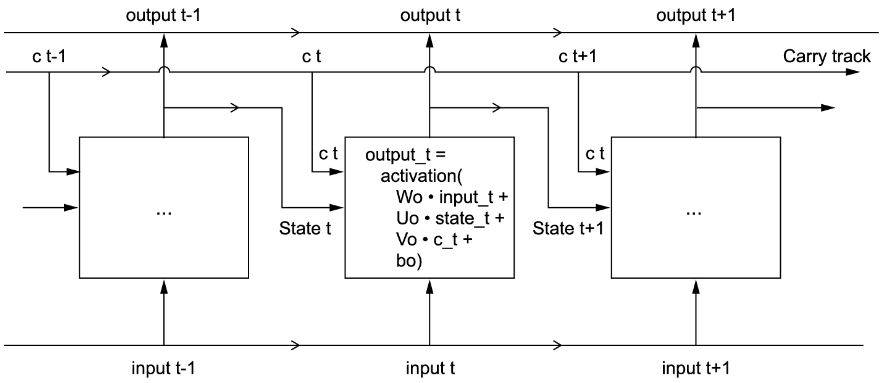

In [12]:
from tensorflow import keras
from tensorflow.keras import layers

num_features = 14
steps = 120

inputs = keras.Input(shape=(steps, num_features))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="jena_lstm.krs",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

model = keras.models.load_model("jena_lstm.krs")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 [==============================] - 50s 58ms/step - loss: 41.9012 - mae: 4.7108 - val_loss: 12.4633 - val_mae: 2.6705
Epoch 2/10
819/819 [==============================] - 54s 65ms/step - loss: 10.9489 - mae: 2.5701 - val_loss: 9.6164 - val_mae: 2.4180
Epoch 3/10
819/819 [==============================] - 47s 57ms/step - loss: 9.8324 - mae: 2.4467 - val_loss: 9.4242 - val_mae: 2.3818
Epoch 4/10
819/819 [==============================] - 46s 56ms/step - loss: 9.5016 - mae: 2.4036 - val_loss: 9.4168 - val_mae: 2.3776
Epoch 5/10
819/819 [==============================] - 50s 61ms/step - loss: 9.2189 - mae: 2.3656 - val_loss: 9.4256 - val_mae: 2.3833
Epoch 6/10
819/819 [==============================] - 42s 51ms/step - loss: 9.0674 - mae: 2.3431 - val_loss: 9.4441 - val_mae: 2.3821
Epoch 7/10
819/819 [==============================] - 43s 52ms/step - loss: 8.8629 - mae: 2.3146 - val_loss: 9.4548 - val_mae: 2.3828
Epoch 8/10
819/819 [==============================] - 43s 5